# Titanic Survival Prediction: Data Exploration

Franciz Emmanuelle Angelo L. Esperanza

franciz.esperanza@gmail.com

Dataset: https://www.kaggle.com/competitions/titanic/overview

## The Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))
%matplotlib inline
%load_ext autoreload
%autoreload 2

This dataset contains records of passengers who were on the Titanic the time it crashed on an iceberg. The `Survived` column is the label that we are trying to predict, where `0` is for Not Survived, and `1` is for Survived.

In emergencies like this, women and children's safety are the utmost priority in evacuation measures. Upper class individuals also tend to have more chances of survival because of their social and financial advantages. We would have to perform an exploratory data analysis to confirm that these patterns are present in the data. Before that, we would need to clean the data first.

In [2]:
titanic_train_df = pd.read_csv('../data/train.csv')
titanic_test_df = pd.read_csv('../data/test.csv')

titanic_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [3]:
titanic_test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 52.8 KB


## Data Cleaning

### Handling Duplicates


Removing duplicate data reduces unnecessary bias from the model. For this dataset, there were no duplicates to remove.

In [4]:
train_dupes = titanic_train_df.duplicated().sum()
test_dupes = titanic_test_df.duplicated().sum()

print(f"Number of duplicate rows in training set: {train_dupes}")
print(f"Number of duplicate rows in test set: {test_dupes}")

Number of duplicate rows in training set: 0
Number of duplicate rows in test set: 0


### Checking minimum and maximum values

Columns can sometimes contain values that are outside of their expected range. This can affect numeric computations and label distributions in later steps. This dataset's columns do not contain any unexpected values.

In [5]:
def check_min_max (df):
    for column in df.columns:
        if df[column].dtype in ['int64', 'float64']:
            min_value = df[column].min()
            max_value = df[column].max()
            print(f"Column: {column}, Min: {min_value}, Max: {max_value}")
    print("\n")

min_max_train = check_min_max(titanic_train_df)
min_max_test= check_min_max(titanic_test_df)

Column: PassengerId, Min: 1, Max: 891
Column: Survived, Min: 0, Max: 1
Column: Pclass, Min: 1, Max: 3
Column: Age, Min: 0.42, Max: 80.0
Column: SibSp, Min: 0, Max: 8
Column: Parch, Min: 0, Max: 6
Column: Fare, Min: 0.0, Max: 512.3292


Column: PassengerId, Min: 892, Max: 1309
Column: Pclass, Min: 1, Max: 3
Column: Age, Min: 0.17, Max: 76.0
Column: SibSp, Min: 0, Max: 8
Column: Parch, Min: 0, Max: 9
Column: Fare, Min: 0.0, Max: 512.3292




### Handling missing data

We have to check how much missing data a column has to know the proper way to handle them. This also allows machine learning models to perform mathematical operations on the data without complications. If a column has < 50% missing data, we can use median (numerical) or mode (categorical) imputation to fill in the blanks. Otherwise, we can consider to drop the column. However, in this case, unknown cabin numbers are indicative of third-class passengers so we are keeping the column.

In [6]:
def check_missing_values(df):
    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    print(missing_df[missing_df['Missing Values'] > 0], '\n')
    return

check_missing_values(titanic_train_df)
check_missing_values(titanic_test_df)


          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467 

       Missing Values  Percentage
Age                86   20.574163
Fare                1    0.239234
Cabin             327   78.229665 



The starting letter of a cabin number is the deck letter. This tells us how close people are to staircases and the lifeboats.

In [7]:
titanic_train_df['CabinCat'] = titanic_train_df['Cabin'].str[0]
titanic_test_df['CabinCat'] = titanic_test_df['Cabin'].str[0]

Now, we imputate numerical columns with the median, and categorical columns with the mode. For the `Cabin` column, we are going to recategorize NaN values to `U` for Unknown

In [8]:
from src.preprocess import handle_missing_values

age_median = titanic_train_df["Age"].median()
fare_median = titanic_train_df["Fare"].median()
embarked_mode = titanic_train_df["Embarked"].mode()[0]

handle_missing_values(titanic_train_df, age_median, fare_median, embarked_mode)
handle_missing_values(titanic_test_df, age_median, fare_median, embarked_mode)

Age median:  28.0
Age median:  28.0


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCat,AgeFilled
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,U,Q,NaN,34.5
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,U,S,NaN,47.0
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,U,Q,NaN,62.0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,U,S,NaN,27.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,U,S,NaN,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,U,S,NaN,28.0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,C,39.0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,U,S,NaN,38.5
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,U,S,NaN,28.0


We also need to encode categorical variables so models can easily process them. Label encoding will suffice for the columns since we are planning to use a tree-based model later.

Moreover, there is a single person stayed in a cabin labelled `T`. Since this cabin is occupied by a first-class passenger, we can group this into the `A` category.

In [9]:
titanic_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    str    
 11  Embarked     891 non-null    str    
 12  CabinCat     204 non-null    str    
 13  AgeFilled    891 non-null    float64
dtypes: float64(3), int64(5), str(6)
memory usage: 133.6 KB


In [10]:
from src.preprocess import encode_categorical_variables

encode_categorical_variables(titanic_train_df)
encode_categorical_variables(titanic_test_df)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCat,AgeFilled
0,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,U,1,7,34.5
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,U,2,7,47.0
2,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,U,1,7,62.0
3,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,U,2,7,27.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,U,2,7,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",0,NaN,0,0,A.5. 3236,8.0500,U,2,7,28.0
414,1306,1,"Oliva y Ocana, Dona. Fermina",1,39.0,0,0,PC 17758,108.9000,C105,0,2,39.0
415,1307,3,"Saether, Mr. Simon Sivertsen",0,38.5,0,0,SOTON/O.Q. 3101262,7.2500,U,2,7,38.5
416,1308,3,"Ware, Mr. Frederick",0,NaN,0,0,359309,8.0500,U,2,7,28.0


## Exploratory Data Analysis

In [11]:
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']
categorical_features = ['Sex', 'Embarked', 'CabinCat', 'Pclass']

To start, we need to look at the distribution of the `Survived` column. There are more people who didn't survive than those who did. Even though there is a class imbalance, it is not too extreme. Thus, oversampling is not required.

<Axes: xlabel='Survived', ylabel='count'>

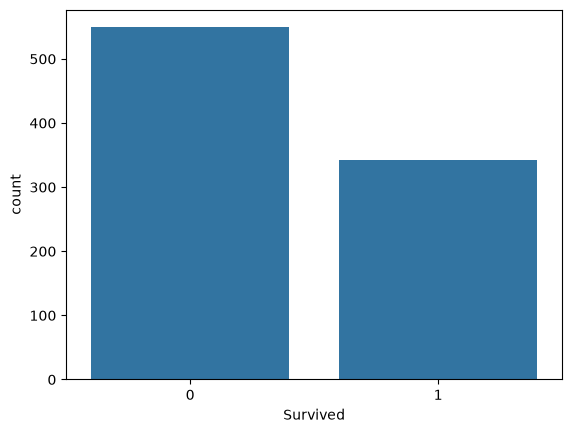

In [12]:
sns.countplot(x='Survived', data=titanic_train_df)

Next, we need to inspect the outliers of the numerical columns. For most cases, outliers need to be removed to prevent data distortion and model confusion. However, in this case, we refrain from dropping them because the dataset is too small and some columns have a lot of outliers.

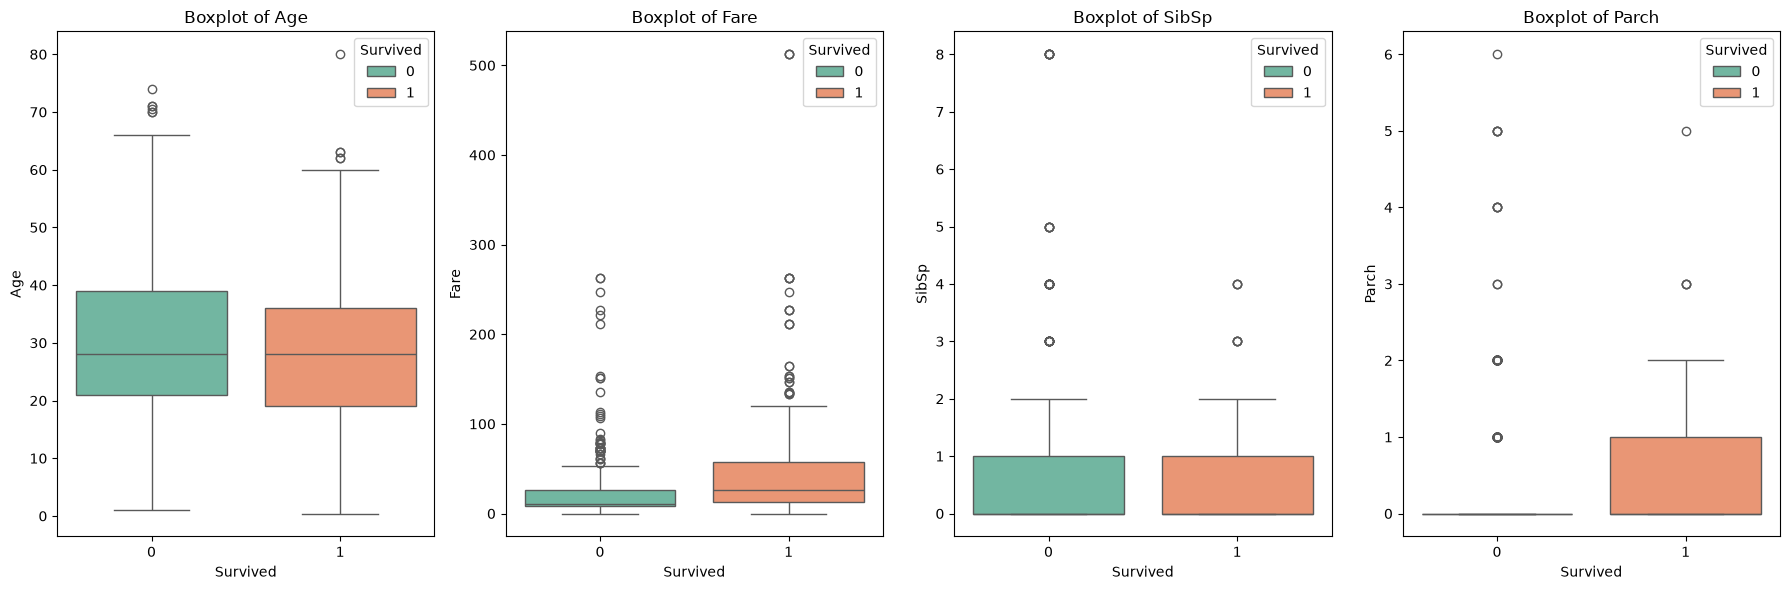

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# Plot boxplots
for i, feature in enumerate(numerical_features):
    if i < len(axes):
        sns.boxplot(data=titanic_train_df, x='Survived', y=feature, ax=axes[i], palette='Set2', hue='Survived')
        axes[i].set_title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()

We can calculate for the outliers using the interquartile range rule. We can also inspect the actual values of these outliers to see if there are unusual values that we can actually remove.

In [14]:
def outlier_summary(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"{column}:\nNumber of Outliers: {len(outliers)}\nPercentage: {len(outliers)/len(df)*100:.2f}%\n")
    print(f"Outlier Values:\n{outliers[column].head(5)}\n")
    return outliers

for feature in numerical_features:
    outlier_summary(titanic_train_df, feature)

Age:
Number of Outliers: 11
Percentage: 1.23%

Outlier Values:
33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
Name: Age, dtype: float64

Fare:
Number of Outliers: 116
Percentage: 13.02%

Outlier Values:
1      71.2833
27    263.0000
31    146.5208
34     82.1708
52     76.7292
Name: Fare, dtype: float64

SibSp:
Number of Outliers: 46
Percentage: 5.16%

Outlier Values:
7     3
16    4
24    3
27    3
50    4
Name: SibSp, dtype: int64

Parch:
Number of Outliers: 213
Percentage: 23.91%

Outlier Values:
7     1
8     2
10    1
13    5
16    1
Name: Parch, dtype: int64



Here, we can see how survival counts vary between age groups. For example, children have higher survival counts than other age groups.

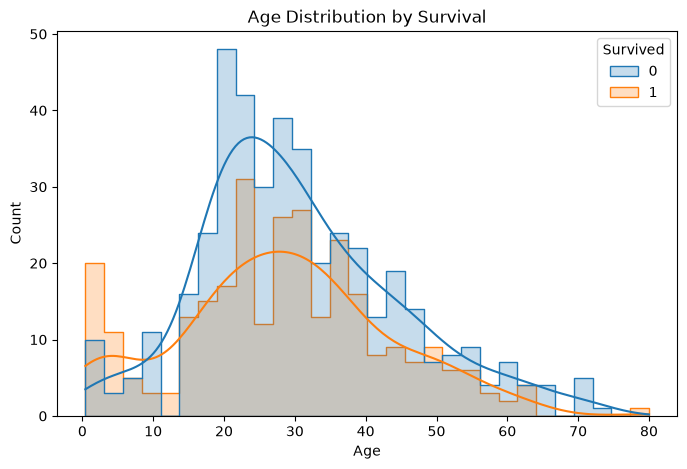

In [15]:

plt.figure(figsize=(8,5))
sns.histplot(data=titanic_train_df, x='Age', hue='Survived', kde=True, bins=30, element='step')
plt.title('Age Distribution by Survival')
plt.show()


Now, we look at the categorical columns' distributions. For the `Sex` column, women are more likely to survive over men. The `Embarked` column plot shows that where a passenger embarked from matters for survival rate. The `CabinCat` column plot tells us that passengers with unknown cabin numbers have a lower survival rate compared to those who have known cabin numbers. Lastly, for the `Pclass` column, survival rate follows a downward trend as social class descends.

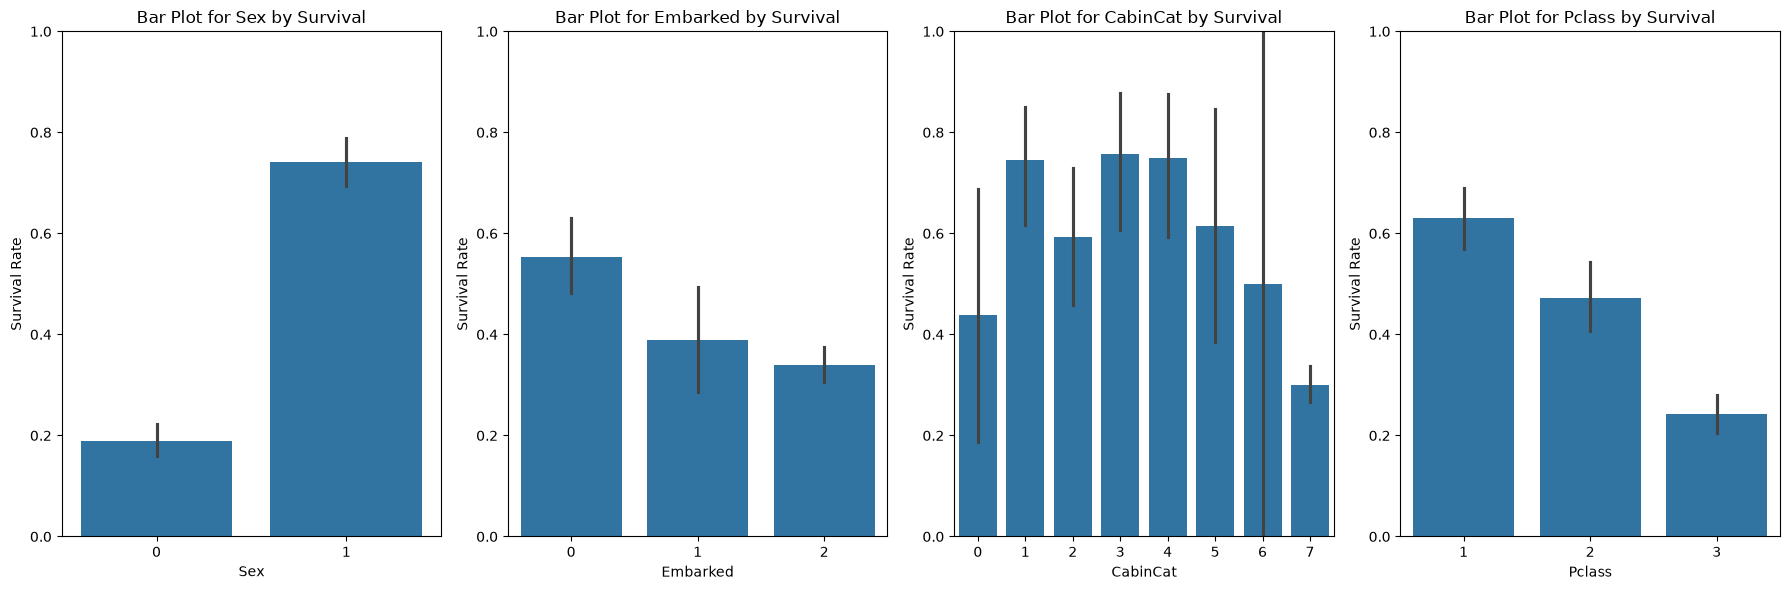

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, col in enumerate(categorical_features):
    if i < len(axes):
        sns.barplot(data=titanic_train_df, x=col, y='Survived', ax=axes[i])
        axes[i].set_title(f'Bar Plot for {col} by Survival')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Survival Rate')
        axes[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Feature Engineering

Now that we've explored the existing patterns in the dataset, we can now do feature engineering to help guide our models to correct predictions.

In [17]:
from src.preprocess import feature_engineering

titanic_train_df = feature_engineering(titanic_train_df)
titanic_test_df = feature_engineering(titanic_test_df)

`FamilySize` tells us how many people a person was travelling with, including themself. The trend shows us that lone travellers and large families (5-8) have a low survival rate, while small families have higher chances of living. Since being alone has potential to be an indicator of survival chance, we can create a `IsAlone` column to make it easier for a model to make that distinction.

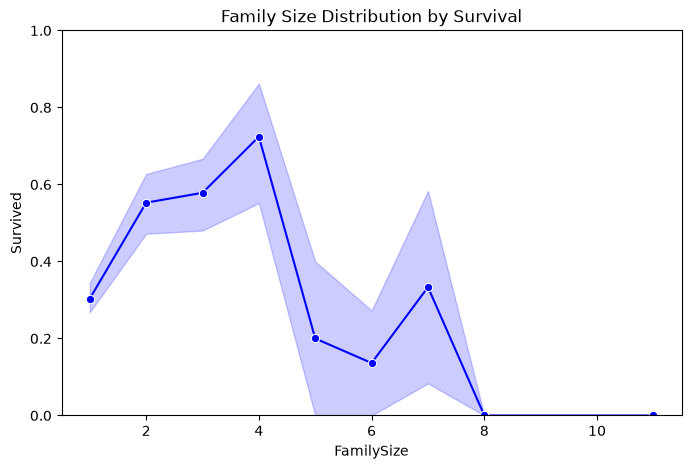

In [18]:
plt.figure(figsize=(8,5))
sns.lineplot(data=titanic_train_df, x='FamilySize', y='Survived', marker='o', color='blue')
plt.title('Family Size Distribution by Survival')
plt.ylim(0, 1)
plt.show()

The original `Fare` column was the total fare of the person's family. To distinguish higher priced fares from one another, we can create the `FarePerPerson` column, which is `Fare` divided by `FamilySize`.

As you can see, there are higher survival counts in higher priced fares. This may indicate that those who can afford these tickets were prioritized during the evacuation.

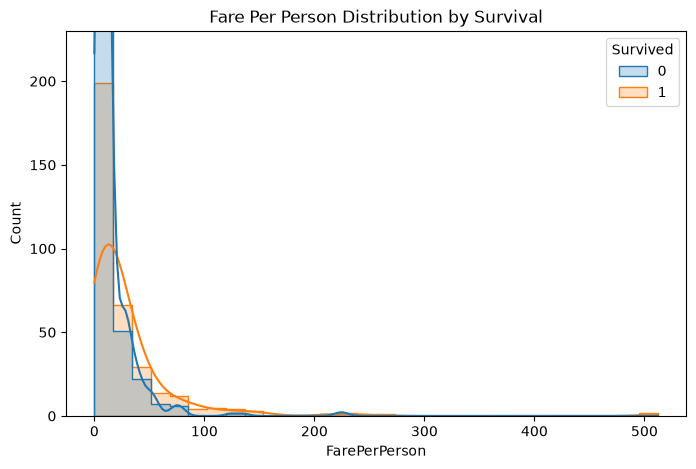

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data=titanic_train_df, x='FarePerPerson', hue='Survived', kde=True, bins=30, element='step')
plt.title('Fare Per Person Distribution by Survival')
plt.ylim(0, 230)
plt.show()

We can also extract a person's title from their `Name` column. The `Title` column can tell us all about a person's sex, class, and age in a single word.

Similar to early graphs, women who have titles such as "Miss" or "Mrs" have higher survival rates. The important distinction that this column provides us is that while adult men (Mr) have low survival rates, young boys (Masters) have higher ones. This coincides with the fact that women and children were prioritized during the evacuation. We also added an `IsChild` column to align with this ruling.

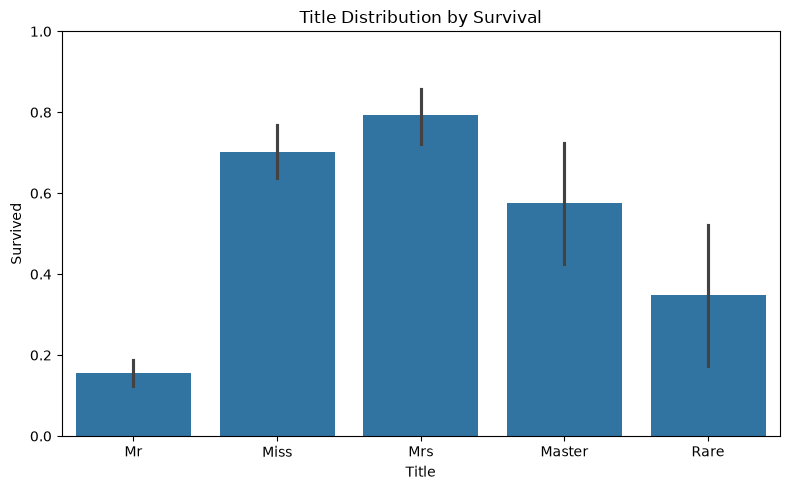

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=titanic_train_df, x='Title', y='Survived')
plt.title('Title Distribution by Survival')
plt.ylim(0, 1)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=["Mr", "Miss", "Mrs", "Master", "Rare"])
plt.tight_layout()
plt.show()

## Last checks

This is what the dataset looks like before model training. There is a lot of redundant columns right now but we will carefully select the columns that we will use in the next part. The model training part will be on `model-training.ipynb`.

In [ ]:
print(titanic_train_df["Title"].unique())

NameError: name 'titan' is not defined

In [ ]:
titanic_train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinCat,AgeFilled,FamilySize,FarePerPerson,IsAlone,IsChild,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,U,2,7,22.0,2,3.62500,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,0,2,38.0,2,35.64165,0,0,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,U,2,7,26.0,1,7.92500,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,2,2,35.0,2,26.55000,0,0,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,U,2,7,35.0,1,8.05000,1,0,0
5,6,0,3,"Moran, Mr. James",0,NaN,0,0,330877,8.4583,U,1,7,28.0,1,8.45830,1,0,0
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,2,4,54.0,1,51.86250,1,0,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,U,2,7,2.0,5,4.21500,0,1,3
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,U,2,7,27.0,3,3.71110,0,0,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,U,0,7,14.0,2,15.03540,0,1,2


: 